# Real Scan Diagnostics

Eight targeted experiments to isolate the 180° registration failure seen on face-forward real scans.

| Section | Question |
|---|---|
| 2 — Coarse correspondences | Are the matched superpoints anatomically sensible? |
| 3 — Scale sweep | Does ICP-derived scale affect the 180° error? |
| 4 — Rotation sweep | Is the error specific to face-forward orientation? |
| 5 — 180° flip correction | Does manually flipping Z restore a good alignment? |
| 6 — Fine correspondences | Are the dense LGR matches coherent after the coarse flip? |
| 7 — Density analysis | Does src point count affect coarse matching? |
| 8 — ICP post-refinement | Can ICP recover from the error, or is it a local-min trap? |

In [1]:
import os, sys

EXP_DIR  = os.path.dirname(os.path.abspath('__file__'))
ROOT_DIR = os.path.dirname(os.path.dirname(EXP_DIR))
sys.path.insert(0, EXP_DIR)
sys.path.insert(0, ROOT_DIR)
os.chdir(EXP_DIR)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation

from config_dowsampled import make_cfg
from dataset import train_valid_data_loader
from model import create_model

from geotransformer.utils.data import precompute_data_stack_mode
from geotransformer.modules.ops import point_to_node_partition, index_select
from geotransformer.modules.ops.transformation import apply_transform

DEVICE = 'cuda'

cfg = make_cfg()
cfg.data.dataset_root = os.path.join(ROOT_DIR, 'data', 'faces')

_, _, neighbor_limits = train_valid_data_loader(cfg, distributed=False)
print('neighbor_limits:', neighbor_limits)

CKPT = os.path.join(
    ROOT_DIR, 'output',
    'geotransformer.facesdownsampledfixed.stage4.gse.k3.max.oacl.stage2.sinkhorn',
    #'3.weightdecay_sigmad0.2',
    'snapshots', 'epoch-6.pth.tar',
)
model = create_model(cfg).to(DEVICE)
model.neighbor_limits = neighbor_limits
ckpt = torch.load(CKPT, map_location=DEVICE)
sd = ckpt.get('model', ckpt)
sd = {k.replace('module.', ''): v for k, v in sd.items()}
model.load_state_dict(sd, strict=False)
model.eval()
print(f'Loaded: {os.path.basename(CKPT)}')

with torch.no_grad():
    mean_ref_pts = model.generate_reference_geometry(torch.zeros(32, 100, device=DEVICE))
mean_ref_np = mean_ref_pts.cpu().numpy()
print(f'Mean ref: {mean_ref_pts.shape}')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
neighbor_limits: [58 25 29 31]
Loaded: epoch-6.pth.tar
Mean ref: torch.Size([10788, 3])


In [2]:
# ── USER CONFIG ───────────────────────────────────────────────────────────────
SCAN_FILE   = 'plank_scaled.npy'   # '2189.npy' or 'plank_scaled.npy'
SCALE_FACTOR = 1 #/ 1.17   # divide raw scan coords by this to reach UHM meter-scale
APPLY_FLIP   = False #True        # flip Y and Z (set False for plank_scaled.npy)
# ─────────────────────────────────────────────────────────────────────────────

raw = np.load(os.path.join(EXP_DIR, SCAN_FILE))
src_np = raw[:, :3].astype(np.float32)
src_pts = torch.from_numpy(src_np).to(DEVICE)

src_pts /= SCALE_FACTOR

if APPLY_FLIP:
    flip = torch.tensor([[1,0,0],[0,1,0],[0,0,-1]], dtype=torch.float32, device=DEVICE)
    src_pts = src_pts @ flip.T

src_pts -= src_pts.mean(dim=0, keepdim=True)
src_np   = src_pts.cpu().numpy()

print(f'Scan      : {SCAN_FILE}  ({src_pts.shape[0]} pts)')
print(f'Src range : x=[{src_np[:,0].min():.3f}, {src_np[:,0].max():.3f}]',
      f'y=[{src_np[:,1].min():.3f}, {src_np[:,1].max():.3f}]',
      f'z=[{src_np[:,2].min():.3f}, {src_np[:,2].max():.3f}]')

Scan      : plank_scaled.npy  (2000 pts)
Src range : x=[-0.642, 0.668] y=[-0.750, 0.835] z=[-0.416, 0.377]


In [3]:
# ── Plotly helpers ────────────────────────────────────────────────────────────
def pcd_trace(pts, color, name, size=2, opacity=0.7):
    return go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(size=size, color=color, opacity=opacity),
        name=name,
    )

def show_reg(traces, title, height=600):
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title, height=height,
        scene=dict(aspectmode='data'),
        legend=dict(itemsizing='constant'),
        margin=dict(l=0, r=0, b=0, t=40),
    )
    fig.show()

# ── Rotation utilities ────────────────────────────────────────────────────────
def rot_angle_deg(T):
    if isinstance(T, torch.Tensor):
        R = T[:3, :3].cpu().numpy()
    else:
        R = T[:3, :3]
    cos_val = np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_val)))

def make_Rz_np(theta_deg):
    theta = np.radians(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])

def nn_dist(A_np, B_np):
    A = torch.from_numpy(A_np).float().to(DEVICE)
    B = torch.from_numpy(B_np).float().to(DEVICE)
    dists = torch.cdist(A, B).min(dim=1).values
    return dists.mean().item()

# ── Bypass runner ─────────────────────────────────────────────────────────────
def run_bypass(src_pts_in, ref_pts_in=None, return_pretransformer=False):
    """Backbone → transformer → coarse → Sinkhorn → LGR on arbitrary src/ref.
    Returns a result dict. If return_pretransformer=True also returns ref_fc_raw /
    src_fc_raw (pre-transformer backbone coarse features, dim=1024).
    Always returns KNN intermediates needed by run_from_coarse()."""
    if ref_pts_in is None:
        ref_pts_in = mean_ref_pts
    n_ref = ref_pts_in.shape[0]
    n_src = src_pts_in.shape[0]

    concat_pts = torch.cat([ref_pts_in, src_pts_in], dim=0)
    lengths_cpu = torch.tensor([n_ref, n_src], dtype=torch.int64)

    graph = precompute_data_stack_mode(
        concat_pts.cpu(), lengths_cpu,
        model.num_stages, model.init_voxel_size, model.init_radius, model.neighbor_limits,
    )
    for key in ['points', 'lengths', 'neighbors', 'subsampling', 'upsampling']:
        if key in graph:
            graph[key] = [t.to(DEVICE) for t in graph[key]]

    dd = {**graph, 'features': torch.ones(n_ref + n_src, 1, device=DEVICE)}

    with torch.no_grad():
        feats_list = model.backbone(dd['features'], dd)
        feats_c = feats_list[-1]
        feats_f = feats_list[0]

        ref_len_c = dd['lengths'][-1][0].item()
        ref_len_f = dd['lengths'][1][0].item()
        ref_len   = dd['lengths'][0][0].item()

        pts_c = dd['points'][-1];  ref_pts_c = pts_c[:ref_len_c];  src_pts_c = pts_c[ref_len_c:]
        pts_f = dd['points'][1];   ref_pts_f = pts_f[:ref_len_f];  src_pts_f = pts_f[ref_len_f:]
        pts_0 = dd['points'][0];   ref_pts_0 = pts_0[:ref_len];    src_pts_0 = pts_0[ref_len:]

        _, ref_node_masks, ref_knn_idx, ref_knn_masks = point_to_node_partition(
            ref_pts_f, ref_pts_c, model.num_points_in_patch
        )
        _, src_node_masks, src_knn_idx, src_knn_masks = point_to_node_partition(
            src_pts_f, src_pts_c, model.num_points_in_patch
        )

        ref_pad_f = torch.cat([ref_pts_f, torch.zeros_like(ref_pts_f[:1])], dim=0)
        src_pad_f = torch.cat([src_pts_f, torch.zeros_like(src_pts_f[:1])], dim=0)
        ref_knn_pts = index_select(ref_pad_f, ref_knn_idx, dim=0)
        src_knn_pts = index_select(src_pad_f, src_knn_idx, dim=0)

        ref_fc_raw = feats_c[:ref_len_c]
        src_fc_raw = feats_c[ref_len_c:]
        ref_feats_f = feats_f[:ref_len_f]
        src_feats_f = feats_f[ref_len_f:]

        ref_fc_out, src_fc_out = model.transformer(
            ref_pts_c.unsqueeze(0), src_pts_c.unsqueeze(0),
            ref_fc_raw.unsqueeze(0), src_fc_raw.unsqueeze(0),
        )
        ref_feats_c = F.normalize(ref_fc_out.squeeze(0), p=2, dim=1)
        src_feats_c = F.normalize(src_fc_out.squeeze(0), p=2, dim=1)

        score_matrix = (ref_feats_c @ src_feats_c.T).cpu().numpy()

        ref_ci, src_ci, corr_scores_c = model.coarse_matching(
            ref_feats_c, src_feats_c, ref_node_masks, src_node_masks
        )

        ref_ck_idx = ref_knn_idx[ref_ci];    src_ck_idx = src_knn_idx[src_ci]
        ref_ck_masks = ref_knn_masks[ref_ci]; src_ck_masks = src_knn_masks[src_ci]
        ref_ck_pts   = ref_knn_pts[ref_ci];   src_ck_pts   = src_knn_pts[src_ci]

        ref_pad_ff = torch.cat([ref_feats_f, torch.zeros_like(ref_feats_f[:1])], dim=0)
        src_pad_ff = torch.cat([src_feats_f, torch.zeros_like(src_feats_f[:1])], dim=0)
        ref_ck_feats = index_select(ref_pad_ff, ref_ck_idx, dim=0)
        src_ck_feats = index_select(src_pad_ff, src_ck_idx, dim=0)

        ms = torch.einsum('bnd,bmd->bnm', ref_ck_feats, src_ck_feats) / feats_f.shape[1] ** 0.5
        ms = model.optimal_transport(ms, ref_ck_masks, src_ck_masks)
        if not model.fine_matching.use_dustbin:
            ms = ms[:, :-1, :-1]

        ref_cp, src_cp, cp_scores, est_T = model.fine_matching(
            ref_ck_pts, src_ck_pts, ref_ck_masks, src_ck_masks, ms, corr_scores_c,
        )

    out = dict(
        ref_pts_c=ref_pts_c, src_pts_c=src_pts_c,
        ref_pts_f=ref_pts_f, src_pts_f=src_pts_f,
        ref_pts_0=ref_pts_0, src_pts_0=src_pts_0,
        ref_feats_c=ref_feats_c, src_feats_c=src_feats_c,
        ref_feats_f=ref_feats_f, src_feats_f=src_feats_f,
        score_matrix=score_matrix,
        ref_ci=ref_ci, src_ci=src_ci, corr_scores_c=corr_scores_c,
        ref_corr_pts=ref_cp, src_corr_pts=src_cp, corr_scores=cp_scores,
        estimated_transform=est_T,
        # KNN intermediates — needed by run_from_coarse()
        ref_node_masks=ref_node_masks, src_node_masks=src_node_masks,
        ref_knn_idx=ref_knn_idx,  src_knn_idx=src_knn_idx,
        ref_knn_masks=ref_knn_masks, src_knn_masks=src_knn_masks,
        ref_knn_pts=ref_knn_pts,  src_knn_pts=src_knn_pts,
    )
    if return_pretransformer:
        out['ref_fc_raw'] = ref_fc_raw
        out['src_fc_raw'] = src_fc_raw
    return out


def run_from_coarse(res, ref_ci_new, src_ci_new, corr_scores_new):
    """Re-run Sinkhorn + LGR from new coarse correspondences using an existing
    bypass result (which already has KNN intermediates and fine features)."""
    ref_knn_idx   = res['ref_knn_idx'];   src_knn_idx   = res['src_knn_idx']
    ref_knn_masks = res['ref_knn_masks']; src_knn_masks = res['src_knn_masks']
    ref_knn_pts   = res['ref_knn_pts'];   src_knn_pts   = res['src_knn_pts']
    ref_feats_f   = res['ref_feats_f'];   src_feats_f   = res['src_feats_f']

    with torch.no_grad():
        ref_ck_idx   = ref_knn_idx[ref_ci_new];    src_ck_idx   = src_knn_idx[src_ci_new]
        ref_ck_masks = ref_knn_masks[ref_ci_new];  src_ck_masks = src_knn_masks[src_ci_new]
        ref_ck_pts   = ref_knn_pts[ref_ci_new];    src_ck_pts   = src_knn_pts[src_ci_new]

        ref_pad_ff = torch.cat([ref_feats_f, torch.zeros_like(ref_feats_f[:1])], dim=0)
        src_pad_ff = torch.cat([src_feats_f, torch.zeros_like(src_feats_f[:1])], dim=0)
        ref_ck_feats = index_select(ref_pad_ff, ref_ck_idx, dim=0)
        src_ck_feats = index_select(src_pad_ff, src_ck_idx, dim=0)

        ms = torch.einsum('bnd,bmd->bnm', ref_ck_feats, src_ck_feats) / ref_feats_f.shape[1] ** 0.5
        ms = model.optimal_transport(ms, ref_ck_masks, src_ck_masks)
        if not model.fine_matching.use_dustbin:
            ms = ms[:, :-1, :-1]

        ref_cp, src_cp, cp_scores, est_T = model.fine_matching(
            ref_ck_pts, src_ck_pts, ref_ck_masks, src_ck_masks, ms, corr_scores_new,
        )
    return est_T, ref_cp, src_cp, cp_scores


---
## 2 — Coarse Correspondence Visualization
**Question:** Are the matched Stage-4 superpoints spatially sensible (nose→nose, forehead→forehead)?  
Lines connect each matched ref superpoint to its src superpoint. Color = score rank.

In [4]:
res0 = run_bypass(src_pts)

R0 = res0['estimated_transform']
angle0 = rot_angle_deg(R0)
t0_norm = float(R0[:3, 3].norm().item())
print(f'Estimated R angle : {angle0:.1f}°')
print(f'Estimated t norm  : {t0_norm:.4f} m')
print(f'R diagonal        : {R0[0,0]:.3f}  {R0[1,1]:.3f}  {R0[2,2]:.3f}')
print(f'N coarse corr     : {res0["ref_ci"].shape[0]}')
print(f'Ref superpoints   : {res0["ref_pts_c"].shape[0]}')
print(f'Src superpoints   : {res0["src_pts_c"].shape[0]}')

# Quick raw overlay
show_reg(
    [pcd_trace(mean_ref_np, 'steelblue', 'mean ref'),
     pcd_trace(src_np, 'tomato', 'real scan (raw)')],
    'Baseline: raw starting positions',
)

Estimated R angle : 6.6°
Estimated t norm  : 0.2243 m
R diagonal        : 0.994  0.998  0.995
N coarse corr     : 256
Ref superpoints   : 395
Src superpoints   : 111


In [5]:
ref_pts_c_np  = res0['ref_pts_c'].cpu().numpy()
src_pts_c_np  = res0['src_pts_c'].cpu().numpy()
ref_ci_np     = res0['ref_ci'].cpu().numpy()
src_ci_np     = res0['src_ci'].cpu().numpy()
scores_c_np   = res0['corr_scores_c'].cpu().numpy()

# Color correspondences by rank (bright = high score)
rank_color = (scores_c_np - scores_c_np.min()) / (scores_c_np.max() - scores_c_np.min() + 1e-8)
colors_hex = [f'rgba({int(255*(1-r))},{int(255*r)},0,0.5)' for r in rank_color]

# Build line segments: ref_ci → src_ci (one None-separated polyline)
xs, ys, zs = [], [], []
for ri, si in zip(ref_ci_np, src_ci_np):
    xs += [float(ref_pts_c_np[ri, 0]), float(src_pts_c_np[si, 0]), None]
    ys += [float(ref_pts_c_np[ri, 1]), float(src_pts_c_np[si, 1]), None]
    zs += [float(ref_pts_c_np[ri, 2]), float(src_pts_c_np[si, 2]), None]

line_trace = go.Scatter3d(x=xs, y=ys, z=zs, mode='lines',
                           line=dict(color='gray', width=1), opacity=0.3,
                           name='correspondences', showlegend=True)

fig = go.Figure(data=[
    pcd_trace(ref_pts_c_np, 'steelblue', f'ref superpoints ({len(ref_pts_c_np)})', size=5, opacity=0.5),
    pcd_trace(src_pts_c_np, 'orange',    f'src superpoints ({len(src_pts_c_np)})', size=5, opacity=0.5),
    pcd_trace(ref_pts_c_np[ref_ci_np], 'darkblue', f'ref matched ({len(ref_ci_np)})', size=7),
    pcd_trace(src_pts_c_np[src_ci_np], 'crimson',  f'src matched ({len(src_ci_np)})', size=7),
    line_trace,
])
fig.update_layout(
    title='Coarse correspondences — raw coords (ref=blue, src=orange)',
    height=650, scene=dict(aspectmode='data'), margin=dict(l=0, r=0, b=0, t=40),
)
fig.show()

# Print top-10 by score
top10 = np.argsort(scores_c_np)[::-1][:10]
print('Top-10 coarse matches (ref_pos → src_pos | score):')
for i in top10:
    ri, si = ref_ci_np[i], src_ci_np[i]
    rp = ref_pts_c_np[ri];  sp = src_pts_c_np[si]
    print(f'  ref[{ri:3d}] ({rp[0]:+.3f},{rp[1]:+.3f},{rp[2]:+.3f})'
          f'  →  src[{si:3d}] ({sp[0]:+.3f},{sp[1]:+.3f},{sp[2]:+.3f})'
          f'  score={scores_c_np[i]:.4f}')

Top-10 coarse matches (ref_pos → src_pos | score):
  ref[224] (-0.314,+0.488,+0.311)  →  src[ 15] (+0.309,+0.485,+0.120)  score=0.0006
  ref[253] (-0.090,+0.085,+0.499)  →  src[ 62] (+0.072,+0.093,+0.290)  score=0.0006
  ref[104] (-0.136,+0.307,+0.317)  →  src[ 53] (+0.125,+0.302,+0.125)  score=0.0006
  ref[315] (+0.085,+0.088,+0.482)  →  src[109] (-0.068,+0.077,+0.282)  score=0.0006
  ref[370] (-0.287,+0.317,+0.284)  →  src[ 19] (+0.299,+0.300,+0.049)  score=0.0006
  ref[273] (+0.093,-0.298,+0.446)  →  src[ 82] (-0.046,-0.279,+0.218)  score=0.0006
  ref[234] (+0.072,-0.095,+0.481)  →  src[ 78] (-0.081,-0.092,+0.252)  score=0.0006
  ref[218] (+0.302,-0.102,+0.367)  →  src[ 21] (-0.280,-0.100,+0.088)  score=0.0006
  ref[273] (+0.093,-0.298,+0.446)  →  src[110] (-0.124,-0.330,+0.142)  score=0.0006
  ref[273] (+0.093,-0.298,+0.446)  →  src[ 97] (+0.117,-0.320,+0.166)  score=0.0005


In [6]:
# Score matrix heatmap: rows=ref superpoints, cols=src superpoints
sm = res0['score_matrix']  # shape [N_ref_c, N_src_c]
print(f'Score matrix shape: {sm.shape}   min={sm.min():.4f}  max={sm.max():.4f}')

# Sort ref by Y coord (top of head → chin) for cleaner layout
ref_y_order = np.argsort(ref_pts_c_np[:, 1])[::-1]
sm_sorted = sm[ref_y_order, :]

fig_hm = go.Figure(data=go.Heatmap(
    z=sm_sorted,
    colorscale='Viridis',
    colorbar=dict(title='cos sim'),
))
fig_hm.update_layout(
    title='Coarse score matrix (rows=ref sorted top→chin, cols=src superpoints)',
    xaxis_title='src superpoint index', yaxis_title='ref superpoint (sorted by Y)',
    height=500, margin=dict(l=50, r=20, b=50, t=40),
)
fig_hm.show()

# Show the predicted alignment for reference
src_0_aligned = apply_transform(res0['src_pts_0'], res0['estimated_transform']).cpu().numpy()
show_reg(
    [pcd_trace(res0['ref_pts_0'].cpu().numpy(), 'steelblue', 'ref'),
     pcd_trace(src_0_aligned, 'orange', f'src aligned  (R angle={angle0:.1f}°)')],
    'Baseline predicted alignment',
)

Score matrix shape: (395, 111)   min=-0.6377  max=0.9021


---
## 3 — Scale Sweep
**Question:** Is the 180° error scale-sensitive? Does the model snap to a correct pose at a different scale?  
We multiply `src` coords by `s` and re-run the bypass. The ICP pre-scale should be around 1.0; the sweep exposes whether the coarse matching degrades gracefully or flips at certain scales.

s=0.75  R_angle= 133.1°  t_norm=0.4033  n_corr=256  nn_dist=0.1084
s=0.80  R_angle= 122.6°  t_norm=0.6553  n_corr=256  nn_dist=0.2124
s=0.85  R_angle=   8.0°  t_norm=0.2737  n_corr=256  nn_dist=0.0318
s=0.90  R_angle= 119.3°  t_norm=0.6777  n_corr=256  nn_dist=0.2489
s=0.95  R_angle=   6.0°  t_norm=0.2426  n_corr=256  nn_dist=0.0252
s=1.00  R_angle=   6.6°  t_norm=0.2243  n_corr=256  nn_dist=0.0294
s=1.05  R_angle=   5.4°  t_norm=0.2256  n_corr=256  nn_dist=0.0356
s=1.10  R_angle= 119.9°  t_norm=0.6936  n_corr=256  nn_dist=0.3044
s=1.15  R_angle= 121.0°  t_norm=0.7231  n_corr=256  nn_dist=0.3407
s=1.20  R_angle=   9.5°  t_norm=0.1992  n_corr=256  nn_dist=0.0802
s=1.25  R_angle=  17.1°  t_norm=0.2027  n_corr=256  nn_dist=0.1092


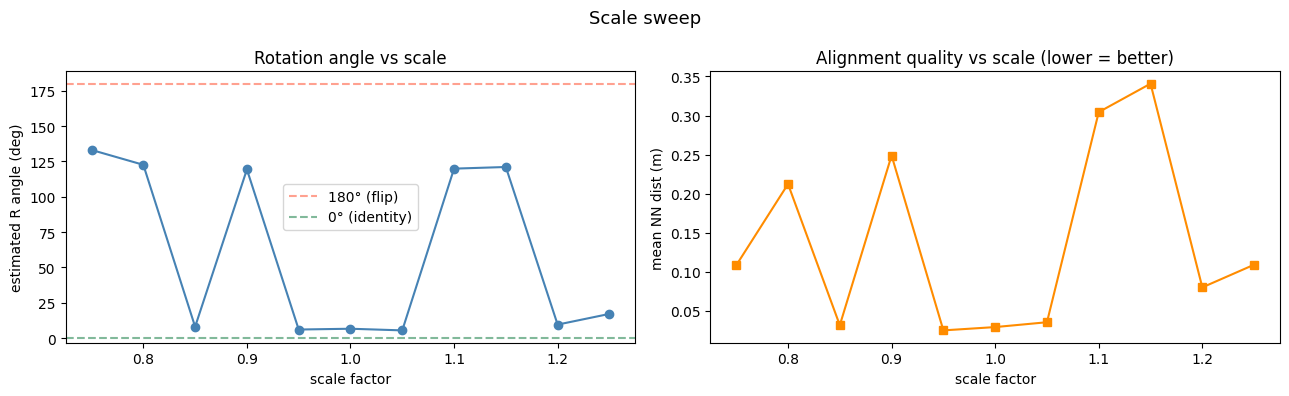

In [7]:
scales = [0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25]
scale_results = []

for s in scales:
    src_scaled = src_pts * s
    res_s = run_bypass(src_scaled)
    T_s   = res_s['estimated_transform']
    angle = rot_angle_deg(T_s)
    t_n   = float(T_s[:3, 3].norm().item())
    n_corr = res_s['ref_ci'].shape[0]
    # NN dist from aligned src to ref (proxy quality metric)
    src_aln = apply_transform(res_s['src_pts_0'], T_s).cpu().numpy()
    d_nn = nn_dist(src_aln, mean_ref_np)
    scale_results.append(dict(scale=s, angle=angle, t_norm=t_n, n_corr=n_corr, nn_dist=d_nn))
    print(f's={s:.2f}  R_angle={angle:6.1f}°  t_norm={t_n:.4f}  n_corr={n_corr}  nn_dist={d_nn:.4f}')

# Plot
scales_arr = [r['scale'] for r in scale_results]
angles_arr = [r['angle'] for r in scale_results]
nn_arr     = [r['nn_dist'] for r in scale_results]

fig_sw, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig_sw.suptitle('Scale sweep', fontsize=13)

ax1.plot(scales_arr, angles_arr, 'o-', color='steelblue')
ax1.axhline(180, color='tomato', linestyle='--', alpha=0.6, label='180° (flip)')
ax1.axhline(0,   color='seagreen', linestyle='--', alpha=0.6, label='0° (identity)')
ax1.set_xlabel('scale factor'); ax1.set_ylabel('estimated R angle (deg)')
ax1.set_title('Rotation angle vs scale'); ax1.legend()

ax2.plot(scales_arr, nn_arr, 's-', color='darkorange')
ax2.set_xlabel('scale factor'); ax2.set_ylabel('mean NN dist (m)')
ax2.set_title('Alignment quality vs scale (lower = better)')

plt.tight_layout(); plt.show()

In [8]:
# Show alignment for three representative scales
viz_scales = [0.85, 1.00, 1.15]
for s in viz_scales:
    src_s = src_pts * s
    res_s = run_bypass(src_s)
    T_s   = res_s['estimated_transform']
    aln   = apply_transform(res_s['src_pts_0'], T_s).cpu().numpy()
    show_reg(
        [pcd_trace(res_s['ref_pts_0'].cpu().numpy(), 'steelblue', 'ref'),
         pcd_trace(aln, 'orange', f'src (scale={s})')],
        f'Scale={s}  R_angle={rot_angle_deg(T_s):.1f}°',
    )

---
## 4 — Rotation Sweep (180° Hypothesis Test)
**Question:** Is the 180° error specific to the face-forward (θ=0°) starting pose, or does the model
always predict ~180° regardless of initial orientation?

We pre-rotate `src` around the Z-axis by θ ∈ {0°, 45°, …, 315°} and measure the **residual angle**:
how far is `R_pred` from the expected `Rz(−θ)` (what a perfect model would output).

- Residual ≈ 0°  for all θ → model works; failure is a preprocessing issue.
- Residual ≈ 180° only at θ=0° → coarse matching systematically flips face-forward inputs.
- Residual roughly constant → model learned a fixed biased rotation.

θ=  0°  R_pred_angle=   6.6°  residual=   6.6°
θ= 45°  R_pred_angle=  45.6°  residual=   7.0°
θ= 90°  R_pred_angle=  90.6°  residual=   3.8°
θ=135°  R_pred_angle= 137.1°  residual=   4.8°
θ=180°  R_pred_angle= 179.5°  residual=   5.8°
θ=225°  R_pred_angle= 137.2°  residual=   6.0°
θ=270°  R_pred_angle=  91.9°  residual=   5.7°
θ=315°  R_pred_angle=  50.4°  residual=   9.0°


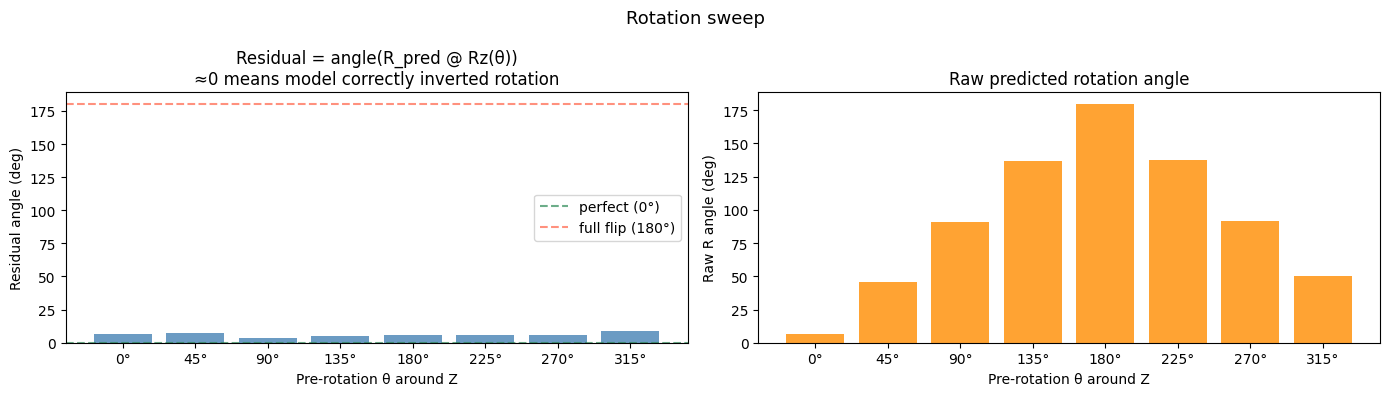

In [9]:
theta_degs = list(range(0, 360, 45))  # 0,45,90,...,315
rot_results = []

for theta in theta_degs:
    # Apply Rz(theta) to src (row-vector convention: pts @ Rz.T)
    Rz = make_Rz_np(theta)
    src_rot_np = src_np @ Rz.T
    src_rot    = torch.from_numpy(src_rot_np).float().to(DEVICE)

    res_r = run_bypass(src_rot)
    T_r   = res_r['estimated_transform']
    R_pred = T_r[:3, :3].cpu().numpy()

    # The perfect inverse of the pre-rotation is Rz(-theta)
    # Residual: R_pred @ Rz(theta) should be ≈ I
    R_res = R_pred @ Rz
    cos_val = np.clip((np.trace(R_res) - 1) / 2, -1.0, 1.0)
    residual = float(np.degrees(np.arccos(cos_val)))
    raw_angle = rot_angle_deg(T_r)

    rot_results.append(dict(theta=theta, residual=residual, raw_angle=raw_angle))
    print(f'θ={theta:3d}°  R_pred_angle={raw_angle:6.1f}°  residual={residual:6.1f}°')

# Bar chart
thetas   = [r['theta']   for r in rot_results]
residuals = [r['residual'] for r in rot_results]
raw_angles = [r['raw_angle'] for r in rot_results]

x = np.arange(len(thetas))
fig_r, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 4))
fig_r.suptitle('Rotation sweep', fontsize=13)

ax_a.bar(x, residuals, color='steelblue', alpha=0.8)
ax_a.axhline(0,   color='seagreen', linestyle='--', alpha=0.7, label='perfect (0°)')
ax_a.axhline(180, color='tomato',   linestyle='--', alpha=0.7, label='full flip (180°)')
ax_a.set_xticks(x); ax_a.set_xticklabels([f'{t}°' for t in thetas])
ax_a.set_xlabel('Pre-rotation θ around Z'); ax_a.set_ylabel('Residual angle (deg)')
ax_a.set_title('Residual = angle(R_pred @ Rz(θ))\n≈0 means model correctly inverted rotation')
ax_a.legend()

ax_b.bar(x, raw_angles, color='darkorange', alpha=0.8)
ax_b.set_xticks(x); ax_b.set_xticklabels([f'{t}°' for t in thetas])
ax_b.set_xlabel('Pre-rotation θ around Z'); ax_b.set_ylabel('Raw R angle (deg)')
ax_b.set_title('Raw predicted rotation angle')

plt.tight_layout(); plt.show()

---
## 5 — 180° Flip Correction
**Question:** Does applying a 180° rotation around Z as a post-correction recover a good alignment?  
We modify `estimated_transform` by pre-multiplying with `R_fix = diag(−1,−1,+1)` and compare NN distances.

In [10]:
T_pred = res0['estimated_transform']  # baseline (face-forward scan)
src_pts_0  = res0['src_pts_0']
ref_pts_0  = res0['ref_pts_0']

# 180° flip around Z: diag(-1,-1,1) in rotation block
R_fix = torch.tensor([
    [-1.0,  0.0, 0.0, 0.0],
    [ 0.0, -1.0, 0.0, 0.0],
    [ 0.0,  0.0, 1.0, 0.0],
    [ 0.0,  0.0, 0.0, 1.0],
], device=DEVICE)

# Apply flip: first align with T_pred, then rotate the result by R_fix
T_flipped = R_fix @ T_pred  # combined transform

src_aligned_pred    = apply_transform(src_pts_0, T_pred).cpu().numpy()
src_aligned_flipped = apply_transform(src_pts_0, T_flipped).cpu().numpy()
ref_np0 = ref_pts_0.cpu().numpy()

nn_pred    = nn_dist(src_aligned_pred,    ref_np0)
nn_flipped = nn_dist(src_aligned_flipped, ref_np0)
print(f'NN dist (pred)          : {nn_pred:.4f} m')
print(f'NN dist (flip-corrected): {nn_flipped:.4f} m')
print(f'Improvement ratio       : {nn_pred / (nn_flipped + 1e-9):.2f}x')

show_reg(
    [pcd_trace(ref_np0, 'steelblue', 'ref'),
     pcd_trace(src_aligned_pred, 'tomato', f'pred  (NN={nn_pred:.4f}m)')],
    'Predicted alignment (no correction)',
)
show_reg(
    [pcd_trace(ref_np0, 'steelblue', 'ref'),
     pcd_trace(src_aligned_flipped, 'seagreen', f'flip-corrected  (NN={nn_flipped:.4f}m)')],
    '180° Z-flip corrected alignment',
)

NN dist (pred)          : 0.0294 m
NN dist (flip-corrected): 0.0869 m
Improvement ratio       : 0.34x


---
## 6 — Fine Correspondence Visualization
**Question:** Are the dense LGR inlier correspondences coherent (anatomically matched) or scattered?  
Color = correspondence score (bright = high confidence).

In [11]:
ref_cp_np  = res0['ref_corr_pts'].cpu().numpy()   # matched ref points
src_cp_np  = res0['src_corr_pts'].cpu().numpy()   # matched src points (pre-transform)
cp_scores  = res0['corr_scores'].cpu().numpy()

print(f'Fine correspondences: {len(ref_cp_np)} inlier pairs')
print(f'Score range: [{cp_scores.min():.4f}, {cp_scores.max():.4f}]  mean={cp_scores.mean():.4f}')

# Draw lines from ref corr pts to src corr pts (pre-transform)
xs_f, ys_f, zs_f = [], [], []
for rp, sp in zip(ref_cp_np, src_cp_np):
    xs_f += [float(rp[0]), float(sp[0]), None]
    ys_f += [float(rp[1]), float(sp[1]), None]
    zs_f += [float(rp[2]), float(sp[2]), None]

fig_fc = go.Figure(data=[
    go.Scatter3d(x=xs_f, y=ys_f, z=zs_f, mode='lines',
                 line=dict(color='gray', width=1), opacity=0.25, name='fine corr lines'),
    go.Scatter3d(
        x=ref_cp_np[:, 0], y=ref_cp_np[:, 1], z=ref_cp_np[:, 2],
        mode='markers',
        marker=dict(size=4, color=cp_scores, colorscale='Viridis',
                    colorbar=dict(title='score'), opacity=0.9),
        name='ref corr pts',
    ),
    go.Scatter3d(
        x=src_cp_np[:, 0], y=src_cp_np[:, 1], z=src_cp_np[:, 2],
        mode='markers',
        marker=dict(size=4, color=cp_scores, colorscale='Plasma', opacity=0.9),
        name='src corr pts (raw)',
    ),
])
fig_fc.update_layout(
    title='Fine correspondences — ref (Viridis) ↔ src (Plasma), color=score',
    height=650, scene=dict(aspectmode='data'), margin=dict(l=0, r=0, b=0, t=40),
)
fig_fc.show()

# Show src corr pts after predicted transform for comparison
src_cp_tensor = res0['src_corr_pts']
src_cp_aligned = apply_transform(src_cp_tensor, res0['estimated_transform']).cpu().numpy()
show_reg(
    [pcd_trace(ref_cp_np, 'steelblue', 'ref corr pts'),
     pcd_trace(src_cp_aligned, 'orange', 'src corr pts (after pred T)')],
    'Fine corr pts after applying predicted transform',
)

Fine correspondences: 3870 inlier pairs
Score range: [0.0500, 0.5100]  mean=0.1310


---
## 7 — Density Analysis
**Question:** Does the number of src points affect the coarse superpoint count and matching quality?

ratio=0.20  n_src=  400  n_src_c=  91  n_corr= 256  angle=  35.3°  nn_dist=0.1137
ratio=0.35  n_src=  700  n_src_c= 102  n_corr= 256  angle= 138.0°  nn_dist=0.1080
ratio=0.50  n_src= 1000  n_src_c= 106  n_corr= 256  angle=  14.3°  nn_dist=0.0494
ratio=0.65  n_src= 1300  n_src_c= 108  n_corr= 256  angle= 115.0°  nn_dist=0.2650
ratio=0.80  n_src= 1600  n_src_c= 111  n_corr= 256  angle=  95.9°  nn_dist=0.2833
ratio=1.00  n_src= 2000  n_src_c= 111  n_corr= 256  angle=   6.6°  nn_dist=0.0296

 ratio   n_src  n_src_c  n_corr   R_angle   NN_dist
-------------------------------------------------------
  0.20     400       91     256     35.3°    0.1137
  0.35     700      102     256    138.0°    0.1080
  0.50    1000      106     256     14.3°    0.0494
  0.65    1300      108     256    115.0°    0.2650
  0.80    1600      111     256     95.9°    0.2833
  1.00    2000      111     256      6.6°    0.0296


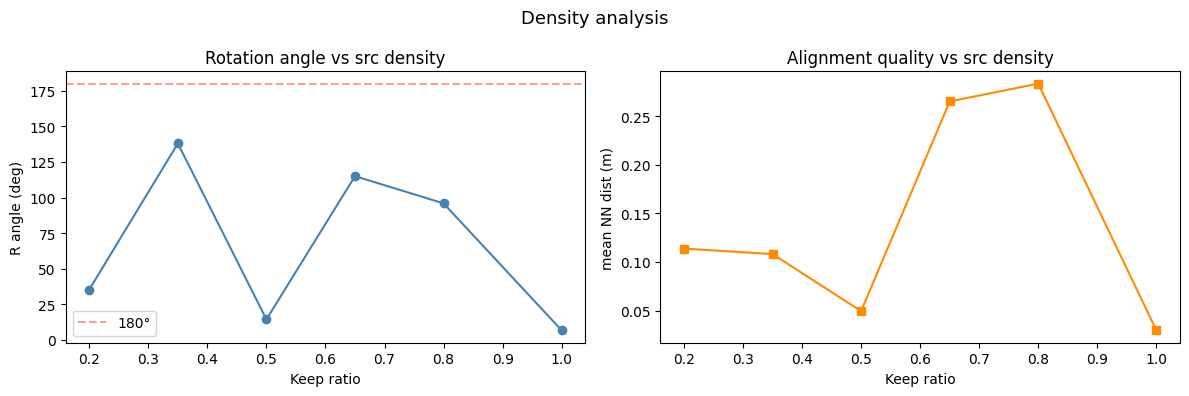

In [12]:
keep_ratios = [0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
density_results = []

rng = np.random.default_rng(42)
for ratio in keep_ratios:
    n_keep = max(50, int(len(src_np) * ratio))
    idx = rng.choice(len(src_np), size=n_keep, replace=False)
    src_sub = torch.from_numpy(src_np[idx]).float().to(DEVICE)

    res_d = run_bypass(src_sub)
    T_d   = res_d['estimated_transform']
    angle = rot_angle_deg(T_d)
    n_src_c = res_d['src_pts_c'].shape[0]
    n_corr  = res_d['ref_ci'].shape[0]
    aln = apply_transform(res_d['src_pts_0'], T_d).cpu().numpy()
    d_nn = nn_dist(aln, mean_ref_np)

    density_results.append(dict(
        ratio=ratio, n_src=n_keep, n_src_c=n_src_c,
        n_corr=n_corr, angle=angle, nn_dist=d_nn,
    ))
    print(f'ratio={ratio:.2f}  n_src={n_keep:5d}  n_src_c={n_src_c:4d}'
          f'  n_corr={n_corr:4d}  angle={angle:6.1f}°  nn_dist={d_nn:.4f}')

# Table
print()
print(f'{"ratio":>6} {"n_src":>7} {"n_src_c":>8} {"n_corr":>7} {"R_angle":>9} {"NN_dist":>9}')
print('-' * 55)
for r in density_results:
    print(f'{r["ratio"]:>6.2f} {r["n_src"]:>7d} {r["n_src_c"]:>8d} {r["n_corr"]:>7d}'
          f' {r["angle"]:>8.1f}° {r["nn_dist"]:>9.4f}')

# Plot
ratios_arr = [r['ratio'] for r in density_results]
angles_d   = [r['angle'] for r in density_results]
nns_d      = [r['nn_dist'] for r in density_results]

fig_d, (ax_d1, ax_d2) = plt.subplots(1, 2, figsize=(12, 4))
fig_d.suptitle('Density analysis', fontsize=13)

ax_d1.plot(ratios_arr, angles_d, 'o-', color='steelblue')
ax_d1.axhline(180, color='tomato', linestyle='--', alpha=0.6, label='180°')
ax_d1.set_xlabel('Keep ratio'); ax_d1.set_ylabel('R angle (deg)')
ax_d1.set_title('Rotation angle vs src density'); ax_d1.legend()

ax_d2.plot(ratios_arr, nns_d, 's-', color='darkorange')
ax_d2.set_xlabel('Keep ratio'); ax_d2.set_ylabel('mean NN dist (m)')
ax_d2.set_title('Alignment quality vs src density')

plt.tight_layout(); plt.show()

---
## 8 — ICP Post-Refinement
**Question:** Can ICP escape the 180° local minimum, or does it converge to the same wrong solution?  
Run point-to-point ICP twice: once from `estimated_transform`, once from the Z-flip-corrected init.  
If ICP from the flipped init converges with high fitness, the LGR result is a local-min trap and
a heuristic post-flip + ICP could be a short-term fix while retraining.

In [13]:
import open3d as o3d

ICP_DIST  = 0.05   # max correspondence distance (m)
ICP_ITERS = 200

ref_pts_0_np = res0['ref_pts_0'].cpu().numpy()
src_pts_0_np = res0['src_pts_0'].cpu().numpy()

ref_o3d = o3d.geometry.PointCloud()
ref_o3d.points = o3d.utility.Vector3dVector(ref_pts_0_np)

src_o3d = o3d.geometry.PointCloud()
src_o3d.points = o3d.utility.Vector3dVector(src_pts_0_np)

T_pred_np    = res0['estimated_transform'].cpu().numpy().astype(np.float64)
T_flipped_np = (R_fix @ res0['estimated_transform']).cpu().numpy().astype(np.float64)

criteria = o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=ICP_ITERS)
method   = o3d.pipelines.registration.TransformationEstimationPointToPoint()

icp_from_pred = o3d.pipelines.registration.registration_icp(
    src_o3d, ref_o3d, ICP_DIST, T_pred_np, method, criteria,
)
icp_from_flip = o3d.pipelines.registration.registration_icp(
    src_o3d, ref_o3d, ICP_DIST, T_flipped_np, method, criteria,
)

print('ICP from predicted transform:')
print(f'  fitness     : {icp_from_pred.fitness:.4f}')
print(f'  inlier RMSE : {icp_from_pred.inlier_rmse:.6f} m')
print()
print('ICP from flip-corrected transform:')
print(f'  fitness     : {icp_from_flip.fitness:.4f}')
print(f'  inlier RMSE : {icp_from_flip.inlier_rmse:.6f} m')

T_icp_pred = torch.from_numpy(icp_from_pred.transformation.astype(np.float32)).to(DEVICE)
T_icp_flip = torch.from_numpy(icp_from_flip.transformation.astype(np.float32)).to(DEVICE)

src_icp_pred = apply_transform(res0['src_pts_0'], T_icp_pred).cpu().numpy()
src_icp_flip = apply_transform(res0['src_pts_0'], T_icp_flip).cpu().numpy()

nn_icp_pred = nn_dist(src_icp_pred, ref_pts_0_np)
nn_icp_flip = nn_dist(src_icp_flip, ref_pts_0_np)
print(f'\nNN dist after ICP (from pred init) : {nn_icp_pred:.4f} m')
print(f'NN dist after ICP (from flip init) : {nn_icp_flip:.4f} m')

show_reg(
    [pcd_trace(ref_pts_0_np,  'steelblue', 'ref'),
     pcd_trace(src_icp_pred,  'tomato',    f'ICP from pred  (fit={icp_from_pred.fitness:.3f})')],
    f'ICP from predicted init  (RMSE={icp_from_pred.inlier_rmse:.4f} m)',
)
show_reg(
    [pcd_trace(ref_pts_0_np,  'steelblue', 'ref'),
     pcd_trace(src_icp_flip,  'seagreen',  f'ICP from flip  (fit={icp_from_flip.fitness:.3f})')],
    f'ICP from flip-corrected init  (RMSE={icp_from_flip.inlier_rmse:.4f} m)',
)

ICP from predicted transform:
  fitness     : 0.8865
  inlier RMSE : 0.024425 m

ICP from flip-corrected transform:
  fitness     : 0.4440
  inlier RMSE : 0.028740 m

NN dist after ICP (from pred init) : 0.0254 m
NN dist after ICP (from flip init) : 0.0765 m


---
## 9 — Feature Generalization Analysis
**Root question:** Are the coarse features bad because the backbone doesn't generalize (domain gap at input geometry level), or because the transformer degrades them for real scan superpoint configurations?

| Sub-cell | Question |
|---|---|
| 9a — Synthetic baseline | What do good (working) coarse match scores look like? |
| 9b — Pre vs post transformer | Does the transformer help or hurt on real scans? |
| 9c — Feature PCA | Do real scan backbone features land in the synthetic distribution? |
| 9d — Local geometry stats | Does the fine-scale point cloud look different to KPConv? |

The **2×2 table in 9b** is the single most actionable result: it directly assigns blame to backbone vs transformer.

Val pair 0:  ref torch.Size([10788, 3])  src torch.Size([3561, 3])
Src range: x=[0.112,1.386]  y=[-1.844,-0.256]  z=[-0.472,0.917]

--- Synthetic val pair ---
N src superpoints : 131
R angle           : 172.9°
Score matrix      : min=-0.7204  max=0.9447  mean=-0.1066
Coarse corr scores: min=0.0004  max=0.0009  mean=0.0005

--- Real scan (for comparison) ---
N src superpoints : 111
R angle           : 6.6°
Score matrix      : min=-0.6377  max=0.9021  mean=-0.0350
Coarse corr scores: min=0.0002  max=0.0006  mean=0.0003


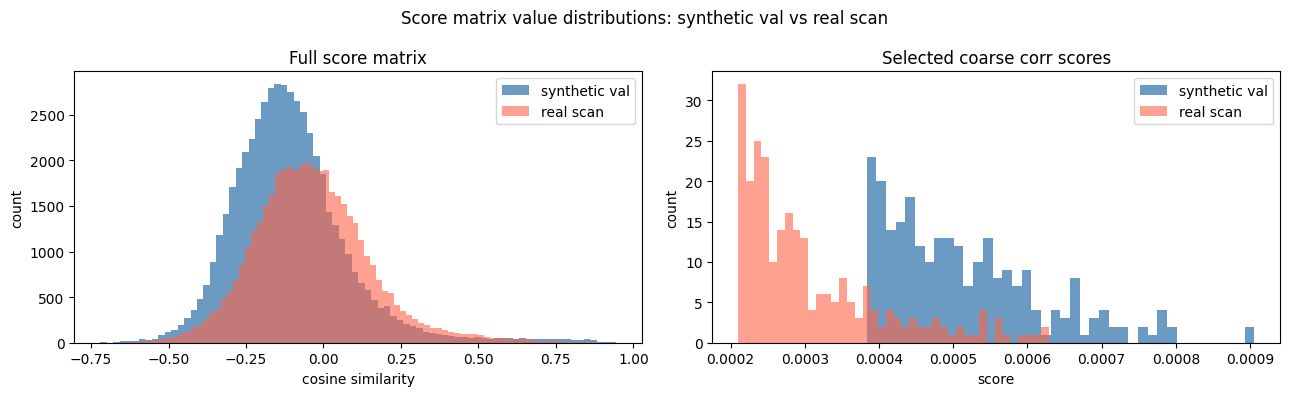

In [14]:
# ── 9a: Synthetic val baseline ────────────────────────────────────────────────
# Load a synthetic val pair and run bypass so we know what "good" scores look like.
# Change VAL_IDX to sample a different val pair.
VAL_IDX = 0

from functools import partial
from geotransformer.utils.data import registration_collate_fn_stack_mode

_, val_loader, _ = train_valid_data_loader(cfg, distributed=False)
val_dataset = val_loader.dataset

# Access ref/src points from the RAW sample (before collation merges them).
raw_sample = val_dataset[VAL_IDX]
syn_ref = torch.from_numpy(raw_sample['ref_points']).float().to(DEVICE)
syn_src = torch.from_numpy(raw_sample['src_points']).float().to(DEVICE)
print(f'Val pair {VAL_IDX}:  ref {syn_ref.shape}  src {syn_src.shape}')
print(f'Src range: x=[{syn_src[:,0].min():.3f},{syn_src[:,0].max():.3f}]'
      f'  y=[{syn_src[:,1].min():.3f},{syn_src[:,1].max():.3f}]'
      f'  z=[{syn_src[:,2].min():.3f},{syn_src[:,2].max():.3f}]')

res_syn = run_bypass(syn_src, syn_ref)
T_syn   = res_syn['estimated_transform']

print(f'\n--- Synthetic val pair ---')
print(f'N src superpoints : {res_syn["src_pts_c"].shape[0]}')
print(f'R angle           : {rot_angle_deg(T_syn):.1f}°')
print(f'Score matrix      : min={res_syn["score_matrix"].min():.4f}'
      f'  max={res_syn["score_matrix"].max():.4f}'
      f'  mean={res_syn["score_matrix"].mean():.4f}')
print(f'Coarse corr scores: min={res_syn["corr_scores_c"].min():.4f}'
      f'  max={res_syn["corr_scores_c"].max():.4f}'
      f'  mean={res_syn["corr_scores_c"].mean():.4f}')
print()
print(f'--- Real scan (for comparison) ---')
print(f'N src superpoints : {res0["src_pts_c"].shape[0]}')
print(f'R angle           : {rot_angle_deg(res0["estimated_transform"]):.1f}°')
print(f'Score matrix      : min={res0["score_matrix"].min():.4f}'
      f'  max={res0["score_matrix"].max():.4f}'
      f'  mean={res0["score_matrix"].mean():.4f}')
print(f'Coarse corr scores: min={res0["corr_scores_c"].min():.4f}'
      f'  max={res0["corr_scores_c"].max():.4f}'
      f'  mean={res0["corr_scores_c"].mean():.4f}')

# Side-by-side score histograms
fig_baseline, axes = plt.subplots(1, 2, figsize=(13, 4))
fig_baseline.suptitle('Score matrix value distributions: synthetic val vs real scan', fontsize=12)
axes[0].hist(res_syn['score_matrix'].flatten(), bins=80, color='steelblue', alpha=0.8, label='synthetic val')
axes[0].hist(res0['score_matrix'].flatten(),    bins=80, color='tomato',    alpha=0.6, label='real scan')
axes[0].set_xlabel('cosine similarity'); axes[0].set_ylabel('count')
axes[0].set_title('Full score matrix'); axes[0].legend()

axes[1].hist(res_syn['corr_scores_c'].cpu().numpy(),  bins=40, color='steelblue', alpha=0.8, label='synthetic val')
axes[1].hist(res0['corr_scores_c'].cpu().numpy(),     bins=40, color='tomato',    alpha=0.6, label='real scan')
axes[1].set_xlabel('score'); axes[1].set_ylabel('count')
axes[1].set_title('Selected coarse corr scores'); axes[1].legend()
plt.tight_layout(); plt.show()

# Show synthetic val alignment
syn_aln = apply_transform(res_syn['src_pts_0'], T_syn).cpu().numpy()
show_reg(
    [pcd_trace(res_syn['ref_pts_0'].cpu().numpy(), 'steelblue', 'ref'),
     pcd_trace(syn_aln, 'orange', f'src aligned  (R={rot_angle_deg(T_syn):.1f}°)')],
    f'Synthetic val pair {VAL_IDX} predicted alignment',
)

──────────────────────────────────────────────────────────
                       pre-transformer   post-transformer
                          max     mean       max     mean
──────────────────────────────────────────────────────────
synthetic val          0.7104   0.2961    0.9447  -0.1066
real scan              0.7315   0.2850    0.9021  -0.0350
──────────────────────────────────────────────────────────

Interpretation:
  • If real-scan pre-transformer max ≈ synthetic → backbone generalizes; transformer is the bottleneck.
  • If real-scan pre-transformer max is already tiny → backbone fails on real scan geometry.
  • If transformer raises synthetic scores but lowers real scan scores → geometric encoding mismatch.


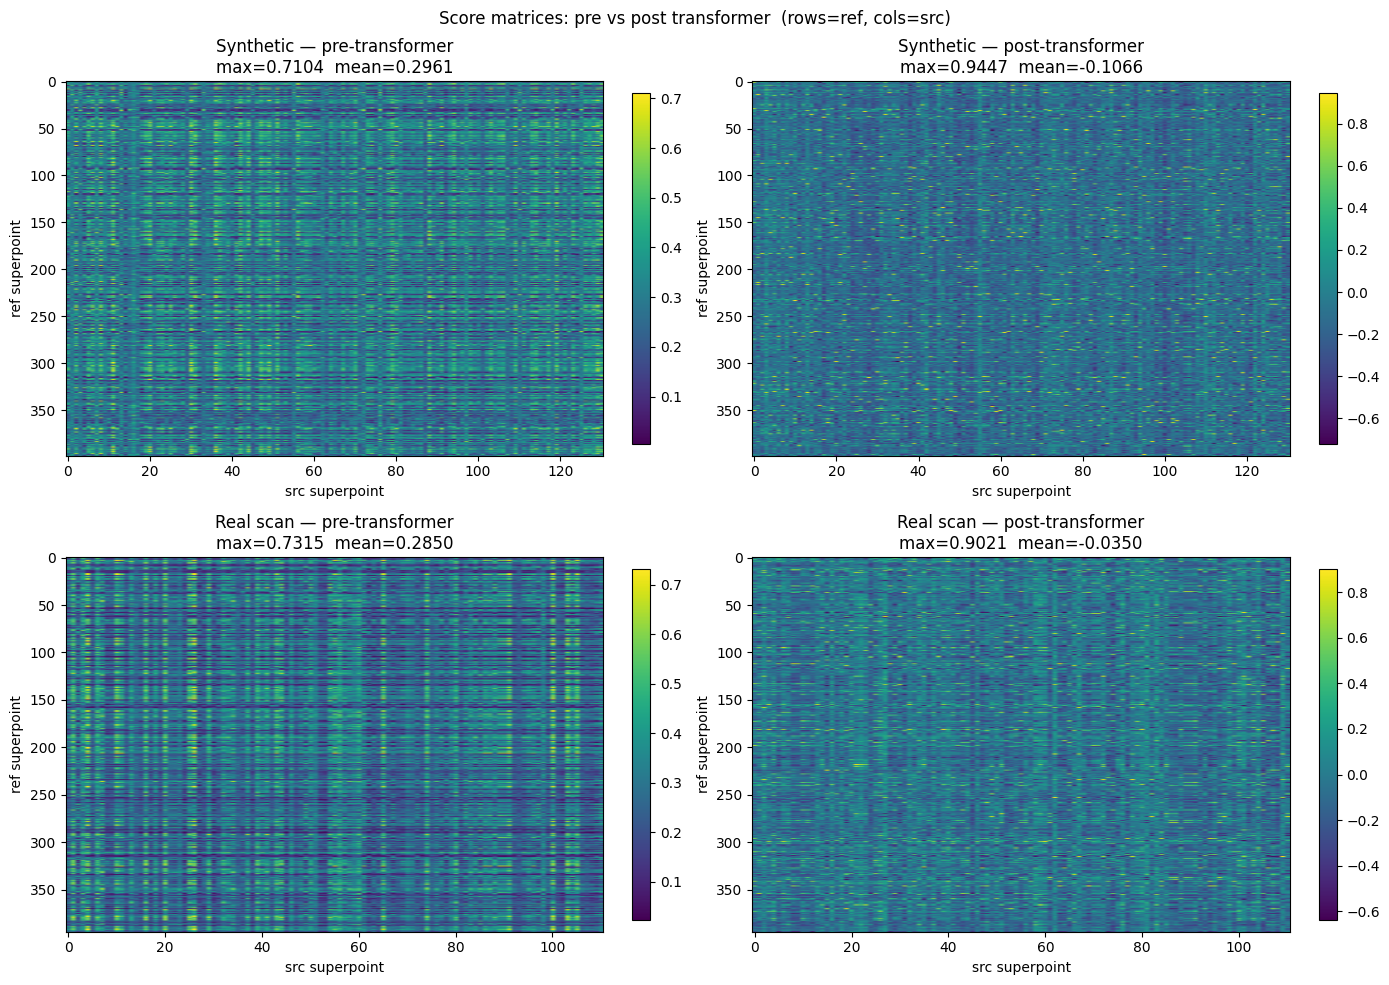

In [15]:
# ── 9b: Pre-transformer vs post-transformer 2×2 table ─────────────────────────
# Runs bypass with return_pretransformer=True for both synthetic val and real scan.
# Then computes cosine sim max before and after the transformer.
# This directly assigns blame: backbone vs transformer.

def score_stats(feat_a, feat_b):
    """Max and mean cosine similarity between two normalized feature sets."""
    fa = F.normalize(feat_a, p=2, dim=1)
    fb = F.normalize(feat_b, p=2, dim=1)
    S = (fa @ fb.T).cpu().numpy()
    return S.max(), S.mean(), S

# Synthetic val
res_syn_pt = run_bypass(syn_src, syn_ref, return_pretransformer=True)
syn_pre_max,  syn_pre_mean,  _ = score_stats(res_syn_pt['ref_fc_raw'], res_syn_pt['src_fc_raw'])
syn_post_max, syn_post_mean, _ = score_stats(res_syn_pt['ref_feats_c'], res_syn_pt['src_feats_c'])

# Real scan
res0_pt = run_bypass(src_pts, return_pretransformer=True)
real_pre_max,  real_pre_mean,  _ = score_stats(res0_pt['ref_fc_raw'], res0_pt['src_fc_raw'])
real_post_max, real_post_mean, _ = score_stats(res0_pt['ref_feats_c'], res0_pt['src_feats_c'])

print('─' * 58)
print(f'{"":20s} {"pre-transformer":>17s}  {"post-transformer":>17s}')
print(f'{"":20s} {"max":>8s} {"mean":>8s}  {"max":>8s} {"mean":>8s}')
print('─' * 58)
print(f'{"synthetic val":20s} {syn_pre_max:8.4f} {syn_pre_mean:8.4f}  {syn_post_max:8.4f} {syn_post_mean:8.4f}')
print(f'{"real scan":20s} {real_pre_max:8.4f} {real_pre_mean:8.4f}  {real_post_max:8.4f} {real_post_mean:8.4f}')
print('─' * 58)
print()
print('Interpretation:')
print('  • If real-scan pre-transformer max ≈ synthetic → backbone generalizes; transformer is the bottleneck.')
print('  • If real-scan pre-transformer max is already tiny → backbone fails on real scan geometry.')
print('  • If transformer raises synthetic scores but lowers real scan scores → geometric encoding mismatch.')

# Also plot score matrices side-by-side (pre vs post, for each)
_, _, syn_pre_S  = score_stats(res_syn_pt['ref_fc_raw'],  res_syn_pt['src_fc_raw'])
_, _, syn_post_S = score_stats(res_syn_pt['ref_feats_c'], res_syn_pt['src_feats_c'])
_, _, real_pre_S  = score_stats(res0_pt['ref_fc_raw'],  res0_pt['src_fc_raw'])
_, _, real_post_S = score_stats(res0_pt['ref_feats_c'], res0_pt['src_feats_c'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Score matrices: pre vs post transformer  (rows=ref, cols=src)', fontsize=12)
for ax, S, title in zip(
    axes.flat,
    [syn_pre_S, syn_post_S, real_pre_S, real_post_S],
    ['Synthetic — pre-transformer', 'Synthetic — post-transformer',
     'Real scan — pre-transformer',  'Real scan — post-transformer'],
):
    im = ax.imshow(S, aspect='auto', cmap='viridis')
    ax.set_title(f'{title}\nmax={S.max():.4f}  mean={S.mean():.4f}')
    ax.set_xlabel('src superpoint'); ax.set_ylabel('ref superpoint')
    fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout(); plt.show()

Extracting backbone features from synthetic val pairs...
  pair 0: ref_c=397  src_c=131
  pair 1: ref_c=400  src_c=118
  pair 2: ref_c=394  src_c=141
  pair 3: ref_c=405  src_c=113
  pair 4: ref_c=398  src_c=135
  pair 5: ref_c=400  src_c=104
  pair 6: ref_c=395  src_c=114
  pair 7: ref_c=399  src_c=149
  pair 8: ref_c=394  src_c=146
  pair 9: ref_c=399  src_c=113

Fitting PCA on 5245 synthetic coarse feature vectors (dim=1024)...
Explained variance ratio: [0.31882438 0.11812423]


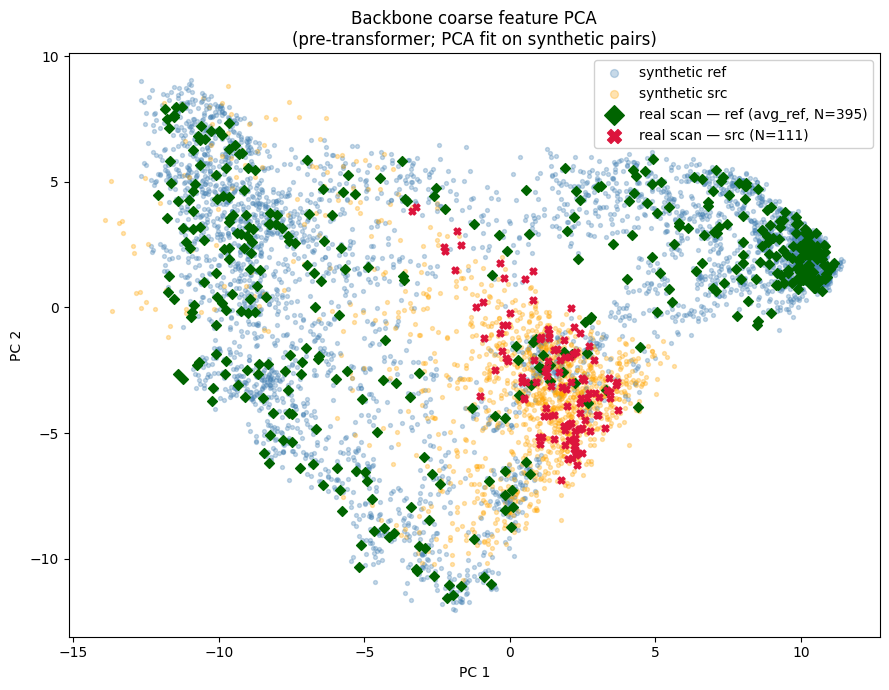


Real scan feature centroid vs synthetic centroid:
  Synthetic centroid    : PC1=-0.000  PC2=-0.000
  Real scan ref centroid: PC1=-0.102  PC2=0.707
  Real scan src centroid: PC1=1.400  PC2=-2.733


In [16]:
# ── 9c: Feature PCA — do real scan features land in the synthetic distribution? ─
# Extract backbone coarse features (pre-transformer) from K synthetic val pairs
# and 1 real scan. Fit PCA on synthetic features, project all onto the same axes.
# If real scan is an outlier → backbone doesn't generalize.

from sklearn.decomposition import PCA

N_SYN_PAIRS = 10   # how many val pairs to use for PCA fitting

print('Extracting backbone features from synthetic val pairs...')
syn_ref_feats_list, syn_src_feats_list = [], []
for i in range(N_SYN_PAIRS):
    raw_i = val_dataset[i]
    ref_i = torch.from_numpy(raw_i['ref_points']).float().to(DEVICE)
    src_i = torch.from_numpy(raw_i['src_points']).float().to(DEVICE)
    res_i = run_bypass(src_i, ref_i, return_pretransformer=True)
    syn_ref_feats_list.append(res_i['ref_fc_raw'].cpu().numpy())
    syn_src_feats_list.append(res_i['src_fc_raw'].cpu().numpy())
    print(f'  pair {i}: ref_c={res_i["ref_pts_c"].shape[0]}  src_c={res_i["src_pts_c"].shape[0]}')

# Stack all synthetic features and fit PCA
all_syn = np.vstack(syn_ref_feats_list + syn_src_feats_list)
print(f'\nFitting PCA on {all_syn.shape[0]} synthetic coarse feature vectors (dim={all_syn.shape[1]})...')
pca = PCA(n_components=2)
pca.fit(all_syn)
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')

# Project everything
syn_ref_proj = [pca.transform(f) for f in syn_ref_feats_list]
syn_src_proj = [pca.transform(f) for f in syn_src_feats_list]

real_ref_proj = pca.transform(res0_pt['ref_fc_raw'].cpu().numpy())
real_src_proj = pca.transform(res0_pt['src_fc_raw'].cpu().numpy())

# Plot
fig_pca, ax = plt.subplots(figsize=(9, 7))
for i, (rp, sp) in enumerate(zip(syn_ref_proj, syn_src_proj)):
    ax.scatter(rp[:, 0], rp[:, 1], c='steelblue', s=8, alpha=0.3,
               label='synthetic ref' if i == 0 else '')
    ax.scatter(sp[:, 0], sp[:, 1], c='orange', s=8, alpha=0.3,
               label='synthetic src' if i == 0 else '')

ax.scatter(real_ref_proj[:, 0], real_ref_proj[:, 1], c='darkgreen', s=25, marker='D',
           label=f'real scan — ref (avg_ref, N={real_ref_proj.shape[0]})', zorder=5)
ax.scatter(real_src_proj[:, 0], real_src_proj[:, 1], c='crimson', s=25, marker='X',
           label=f'real scan — src (N={real_src_proj.shape[0]})', zorder=5)

ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Backbone coarse feature PCA\n(pre-transformer; PCA fit on synthetic pairs)')
ax.legend(markerscale=2, framealpha=0.9)
plt.tight_layout(); plt.show()

print('\nReal scan feature centroid vs synthetic centroid:')
syn_all_proj = np.vstack(syn_ref_proj + syn_src_proj)
print(f'  Synthetic centroid    : PC1={syn_all_proj[:,0].mean():.3f}  PC2={syn_all_proj[:,1].mean():.3f}')
print(f'  Real scan ref centroid: PC1={real_ref_proj[:,0].mean():.3f}  PC2={real_ref_proj[:,1].mean():.3f}')
print(f'  Real scan src centroid: PC1={real_src_proj[:,0].mean():.3f}  PC2={real_src_proj[:,1].mean():.3f}')

Real scan fine-level stats...
  pts=1028  knn_mean=0.0636  plan_mean=-0.4181

Synthetic val pairs...
  pair 0: pts=1100  knn_mean=0.0627  plan_mean=-0.5084
  pair 1: pts=1056  knn_mean=0.0635  plan_mean=-0.4648
  pair 2: pts=1236  knn_mean=0.0652  plan_mean=-0.4474
  pair 3: pts=1081  knn_mean=0.0644  plan_mean=-0.4546
  pair 4: pts=1212  knn_mean=0.0630  plan_mean=-0.5029


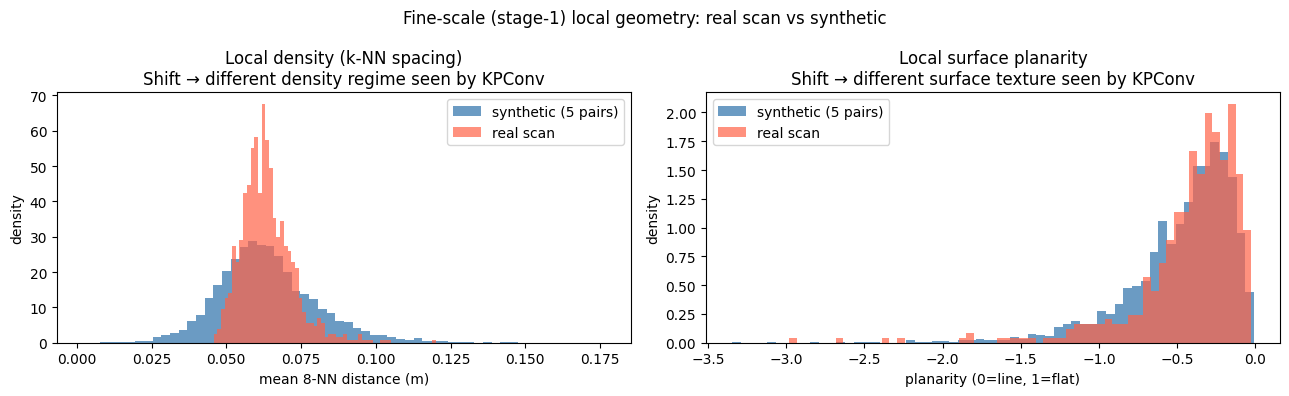


Summary:
  k-NN dist — synthetic : 0.0638 ± 0.0170 m
  k-NN dist — real scan : 0.0636 ± 0.0086 m
  Planarity  — synthetic: -0.4756 ± 0.3553
  Planarity  — real scan: -0.4181 ± 0.3565

Next step depends on 9b result:
  backbone fails  → increase noise aug, adjust density aug, retrain
  transformer fails → geometric encoding mismatch; check sigma_d vs actual pairwise distances
  both similar     → preprocessing/coordinate frame issue


In [17]:
# ── 9d: Local geometry statistics — what does KPConv "see" at fine scale? ─────
# Compare point cloud statistics at the finest backbone level (stage-1 = dd['points'][1])
# for real scan src vs a few synthetic src scans.
# If local geometry is systematically different → KPConv produces out-of-distribution features
# even before the transformer.

def local_knn_stats(pts_tensor, k=8):
    """Returns mean k-NN distance for each point (GPU-accelerated)."""
    D = torch.cdist(pts_tensor, pts_tensor)
    D.fill_diagonal_(float('inf'))
    knn_dists, _ = D.topk(k, dim=1, largest=False)
    return knn_dists.mean(dim=1).cpu().numpy()

def local_planarity(pts_tensor, k=8):
    """Planarity = 1 - λ₁/λ₂ from PCA of k-NN neighborhood.
    Computed on a random subsample of 500 points to keep it fast."""
    n = pts_tensor.shape[0]
    idx = torch.randperm(n, device=pts_tensor.device)[:min(500, n)]
    pts_sub = pts_tensor[idx]
    D = torch.cdist(pts_sub, pts_tensor)
    _, nn_idx = D.topk(k + 1, dim=1, largest=False)
    nn_idx = nn_idx[:, 1:]  # exclude self
    planarities = []
    for i in range(len(pts_sub)):
        nbhd = pts_tensor[nn_idx[i]].cpu().numpy()
        nbhd -= nbhd.mean(axis=0)
        _, sv, _ = np.linalg.svd(nbhd, full_matrices=False)
        planarities.append(1.0 - sv[0] / sv[1] if sv[1] > 1e-8 else 0.0)
    return np.array(planarities)

# ── Real scan ─────────────────────────────────────────────────────────────────
print('Real scan fine-level stats...')
real_pts_f = res0['src_pts_f']
real_knn   = local_knn_stats(real_pts_f)
real_plan  = local_planarity(real_pts_f)
print(f'  pts={real_pts_f.shape[0]}  knn_mean={real_knn.mean():.4f}  plan_mean={real_plan.mean():.4f}')

# ── Synthetic val pairs ───────────────────────────────────────────────────────
print('\nSynthetic val pairs...')
syn_knn_all, syn_plan_all = [], []
for i in range(5):
    raw_i = val_dataset[i]
    ref_i = torch.from_numpy(raw_i['ref_points']).float().to(DEVICE)
    src_i = torch.from_numpy(raw_i['src_points']).float().to(DEVICE)
    res_i = run_bypass(src_i, ref_i)
    pts_f_i = res_i['src_pts_f']
    knn_i   = local_knn_stats(pts_f_i)
    plan_i  = local_planarity(pts_f_i)
    syn_knn_all.append(knn_i)
    syn_plan_all.append(plan_i)
    print(f'  pair {i}: pts={pts_f_i.shape[0]}  knn_mean={knn_i.mean():.4f}  plan_mean={plan_i.mean():.4f}')

syn_knn_flat  = np.concatenate(syn_knn_all)
syn_plan_flat = np.concatenate(syn_plan_all)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_geo, axes = plt.subplots(1, 2, figsize=(13, 4))
fig_geo.suptitle('Fine-scale (stage-1) local geometry: real scan vs synthetic', fontsize=12)

axes[0].hist(syn_knn_flat, bins=60, color='steelblue', alpha=0.8, density=True, label='synthetic (5 pairs)')
axes[0].hist(real_knn,     bins=60, color='tomato',    alpha=0.7, density=True, label='real scan')
axes[0].set_xlabel('mean 8-NN distance (m)'); axes[0].set_ylabel('density')
axes[0].set_title('Local density (k-NN spacing)\nShift → different density regime seen by KPConv')
axes[0].legend()

axes[1].hist(syn_plan_flat, bins=60, color='steelblue', alpha=0.8, density=True, label='synthetic (5 pairs)')
axes[1].hist(real_plan,     bins=60, color='tomato',    alpha=0.7, density=True, label='real scan')
axes[1].set_xlabel('planarity (0=line, 1=flat)'); axes[1].set_ylabel('density')
axes[1].set_title('Local surface planarity\nShift → different surface texture seen by KPConv')
axes[1].legend()

plt.tight_layout(); plt.show()

print('\nSummary:')
print(f'  k-NN dist — synthetic : {syn_knn_flat.mean():.4f} ± {syn_knn_flat.std():.4f} m')
print(f'  k-NN dist — real scan : {real_knn.mean():.4f} ± {real_knn.std():.4f} m')
print(f'  Planarity  — synthetic: {syn_plan_flat.mean():.4f} ± {syn_plan_flat.std():.4f}')
print(f'  Planarity  — real scan: {real_plan.mean():.4f} ± {real_plan.std():.4f}')
print()
print('Next step depends on 9b result:')
print('  backbone fails  → increase noise aug, adjust density aug, retrain')
print('  transformer fails → geometric encoding mismatch; check sigma_d vs actual pairwise distances')
print('  both similar     → preprocessing/coordinate frame issue')

---
## 10 — sigma_d Sweep
**Question:** Does mismatched `sigma_d` explain why the transformer fails to amplify real scan scores?

`sigma_d` is a plain Python attribute on `GeometricStructureEmbedding` — not a learned weight — so it can be patched at inference without reloading the model. The `proj_d` linear layer and attention weights were trained at `sigma_d=0.2`, so any improvement here is **diagnostic** (signals that retraining with a better value is worthwhile), not a real fix.

Table columns: `sigma_d` | `pre_max` | `post_max` | `lift` (post−pre) | `R_angle` | `NN_dist`

 sigma_d  pre_max  post_max    lift   R_angle   NN_dist
----------------------------------------------------------
    0.05   0.7315    0.9354 +0.2040      8.0°    0.0328
    0.10   0.7315    0.8804 +0.1489    128.3°    0.2556
    0.20   0.7315    0.9021 +0.1706      6.6°    0.0294  <-- default
    0.30   0.7315    0.9073 +0.1759      7.0°    0.0297
    0.50   0.7315    0.8670 +0.1355      6.8°    0.0335
    1.00   0.7315    0.9121 +0.1806      4.7°    0.0282

sigma_d restored to 0.2


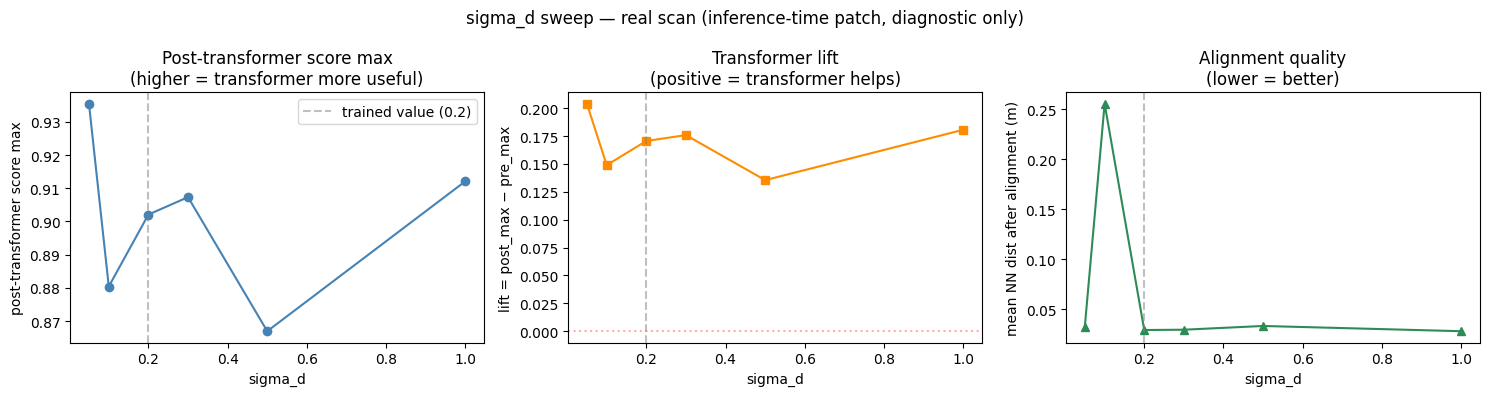

In [18]:
sigma_d_vals = [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
orig_sigma_d = model.transformer.embedding.sigma_d

sweep_results = []
print(f'{"sigma_d":>8} {"pre_max":>8} {"post_max":>9} {"lift":>7} {"R_angle":>9} {"NN_dist":>9}')
print('-' * 58)
for sd in sigma_d_vals:
    model.transformer.embedding.sigma_d = sd
    res_sd = run_bypass(src_pts, return_pretransformer=True)

    pre_max,  _, _ = score_stats(res_sd['ref_fc_raw'],   res_sd['src_fc_raw'])
    post_max, _, _ = score_stats(res_sd['ref_feats_c'],  res_sd['src_feats_c'])
    lift = post_max - pre_max

    T_sd    = res_sd['estimated_transform']
    angle   = rot_angle_deg(T_sd)
    aln     = apply_transform(res_sd['src_pts_0'], T_sd).cpu().numpy()
    nn_d    = nn_dist(aln, mean_ref_np)

    marker = '  <-- default' if abs(sd - 0.2) < 1e-6 else ''
    print(f'{sd:>8.2f} {pre_max:>8.4f} {post_max:>9.4f} {lift:>+7.4f} {angle:>8.1f}° {nn_d:>9.4f}{marker}')
    sweep_results.append(dict(sigma_d=sd, pre_max=pre_max, post_max=post_max,
                              lift=lift, angle=angle, nn_dist=nn_d))

model.transformer.embedding.sigma_d = orig_sigma_d
print(f'\nsigma_d restored to {orig_sigma_d}')

# Plot
sd_arr      = [r['sigma_d']  for r in sweep_results]
post_arr    = [r['post_max'] for r in sweep_results]
nn_arr_sd   = [r['nn_dist']  for r in sweep_results]
lift_arr    = [r['lift']     for r in sweep_results]

fig_sd, axes = plt.subplots(1, 3, figsize=(15, 4))
fig_sd.suptitle('sigma_d sweep — real scan (inference-time patch, diagnostic only)', fontsize=12)

axes[0].plot(sd_arr, post_arr, 'o-', color='steelblue')
axes[0].axvline(0.2, color='gray', linestyle='--', alpha=0.5, label='trained value (0.2)')
axes[0].set_xlabel('sigma_d'); axes[0].set_ylabel('post-transformer score max')
axes[0].set_title('Post-transformer score max\n(higher = transformer more useful)'); axes[0].legend()

axes[1].plot(sd_arr, lift_arr, 's-', color='darkorange')
axes[1].axvline(0.2, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(0,   color='tomato', linestyle=':', alpha=0.5)
axes[1].set_xlabel('sigma_d'); axes[1].set_ylabel('lift = post_max − pre_max')
axes[1].set_title('Transformer lift\n(positive = transformer helps)')

axes[2].plot(sd_arr, nn_arr_sd, '^-', color='seagreen')
axes[2].axvline(0.2, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('sigma_d'); axes[2].set_ylabel('mean NN dist after alignment (m)')
axes[2].set_title('Alignment quality\n(lower = better)')

plt.tight_layout(); plt.show()